In [1]:
%matplotlib inline
from pycocotools.coco import COCO
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
import pylab
import pandas as pd
pylab.rcParams['figure.figsize'] = (8.0, 10.0)

In [2]:
dataDir='..'
dataType='val2017'
annFile='/media/ubuntu/sda/TrippleN/coco/annotations/instances_train2017.json'.format(dataDir,dataType)
coco=COCO(annFile)
annFile = '/media/ubuntu/sda/TrippleN/coco/annotations/captions_train2017.json'.format(dataDir,dataType)
coco_caps=COCO(annFile)

loading annotations into memory...
Done (t=7.80s)
creating index...
index created!
loading annotations into memory...
Done (t=0.31s)
creating index...
index created!


In [5]:
imgIds = coco.getImgIds(imgIds = [262239])
img = coco.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]

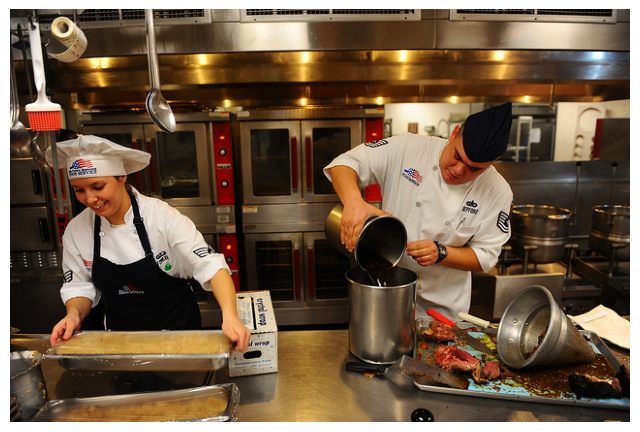

In [6]:
import matplotlib.pyplot as plt
from skimage import io  # scikit-learn 包
I = io.imread(img['coco_url'])
plt.axis('off')
plt.imshow(I)
plt.show()

In [3]:
stimuli = pd.read_csv("/media/ubuntu/sda/TrippleN/nsd_stim_info_merged.csv", index_col=0)
stimuli = stimuli[stimuli['shared1000'] == True]

In [12]:
np.save('stimuli_cocoId.npy', stimuli['cocoId'].values)

In [5]:
# 提取前1000张图片的captions，每张图片5个caption
import pickle

# 获取前1000张stimuli的cocoId
coco_ids = stimuli['cocoId'].values[:1000]
print(f"共有 {len(coco_ids)} 张图片需要提取caption")

# 存储所有captions
captions_matrix = np.zeros((1000, 5), dtype=object)

for idx, coco_id in enumerate(coco_ids):
    # 获取图片信息
    imgIds = coco.getImgIds(imgIds=[coco_id])
    img = coco.loadImgs(imgIds)[0]
    
    # 获取该图片的caption annotations
    annIds = coco_caps.getAnnIds(imgIds=img['id'])
    anns = coco_caps.loadAnns(annIds)
    
    # 取前5个caption
    for j in range(5):
        captions_matrix[idx, j] = anns[j]['caption']
    
    if (idx + 1) % 200 == 0:
        print(f"已处理 {idx + 1}/1000 张图片")

print(f"\nCaption矩阵形状: {captions_matrix.shape}")

# 保存为pickle文件
# output_path = '/media/ubuntu/sda/TrippleN/customize/coco_captions_1000x5.pkl'
# with open(output_path, 'wb') as f:
#     pickle.dump(captions_matrix, f)

# print(f"Caption矩阵已保存到: {output_path}")

共有 1000 张图片需要提取caption
已处理 200/1000 张图片
已处理 400/1000 张图片
已处理 600/1000 张图片
已处理 800/1000 张图片
已处理 1000/1000 张图片

Caption矩阵形状: (1000, 5)
